In [59]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from copy import deepcopy
import pickle as pkl

from matplotlib import pyplot as plt
import matplotlib as mpl

from scipy.spatial.distance import cdist

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model, run_sim_wrapper

from utils import *
from utils_plot import *

from tqdm import tqdm


In [60]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [61]:
def multiclass_functional_margin(W, X, y, reducer=np.min, normalize=1):
    if normalize:
        factor = 1/np.linalg.norm(W)**2
        W = np.sqrt(normalize*factor) * W
    margins = []
    i_max_other_score_l = []
    for x, y_curr in zip(X, y):
        label = y_curr.argmax()
        scores = x@W  # shape (K,)
        true_score = scores[label]
        max_other_score = np.max(np.delete(scores, label))
        i_max_other_score = np.argmax(np.delete(scores, label))
        margins.append(true_score - max_other_score)
        i_max_other_score_l.append(i_max_other_score)
    return reducer(margins), np.argmin(margins), i_max_other_score_l[np.argmin(margins)]

In [62]:

# factor = 1/np.linalg.norm(W)**2
# W_new = np.sqrt(5*factor) * W

In [63]:
# sum([np.linalg.norm(w)**2 for w in W_new.T])

In [ ]:
C = Config()

C.G = 1
# C.sig_h_2 = 1e-2
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
# C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 1
C.L=1
C.print_progress = False
C.length_corridors = [10]*1
# C.input_size = 100
C.max_move = C.length_corridors[0]//2
C.hidden_size = C.length_corridors[0]*3+1 # C.length_corridors[0] * 2 + 1 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1000000
# C.normalize_theta = 10
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()

# Create a serializable dictionary from the Config object
config_dict = {attr: getattr(C, attr) for attr in dir(C) 
               if not attr.startswith('_') and not callable(getattr(C, attr))}

var_name = 'max_move'
var_values = np.linspace(1, C.length_corridors[0]-1, C.length_corridors[0]-1).astype(int)
var_name2 = 'L'
var_values2 = [0, 1, 8]

In [65]:
# Windows-compatible multiprocessing for Jupyter notebooks
from joblib import Parallel, delayed
import os
def process_var_value(var_value, var_name, config_dict, save_dir):
    print(f'Running {var_name} = {var_value}')
    
    # Recreate the Config object from the dictionary
    C = Config()
    for key, value in config_dict.items():
        setattr(C, key, value)
    
    # Set the variable we want to vary
    setattr(C, var_name, var_value)
    
    # Recreate the loss function (it was removed for serialization)
    C.loss_fn = nn.CrossEntropyLoss()
    
    data_dict = run_sim_wrapper(C)
    
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_y = data_dict['loc_y']
    loc_X = data_dict['loc_X']
    # data_dict = {key: data_dict[key] for key in ['final_weights', 'X', 'y', 'action_taken', 'loc_y', 'loc_X', 'hidden_states', 'corridor', 'loss_l', 'accuracy_l', 'C']}

    margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y)
    
    # print(f'Min margin sample: loc_X: {loc_X[min_margin_idx]}, action_taken: {action_taken[min_margin_idx]}, loc_y: {loc_y[min_margin_idx]}, i_max_other_score: {i_max_other_score}')
    
    save_path = os.path.join(save_dir, f'{var_name}_{var_value}.pkl')
    with open(save_path, 'wb') as f:
        pkl.dump(data_dict, f)
    
    return W, margins, min_margin_idx

# Delete the save_dir content if it exists, then recreate it
import shutil
for var2_val in var_values2:
    save_dir = f'results/sweep_{var_name}_with_{var_name2}_{var2_val}'
    if os.path.exists(save_dir):
        shutil.rmtree(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    config_dict[var_name2] = var2_val
    config_dict['learning_rate'] = 1/2**config_dict['L']
    # Use joblib for parallel processing (works better in Jupyter on Windows)
    results = Parallel(n_jobs=9, verbose=10)(
        delayed(process_var_value)(var_value, var_name, config_dict, save_dir) 
        for var_value in var_values
    )

# Unpack results
# W_l, margins_l, min_margin_idx_l, data_dict_l = zip(*results)

# plt.plot(var_values, margins_l)
# plt.show()

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.


[Parallel(n_jobs=9)]: Done   2 out of   9 | elapsed:  9.5min remaining: 33.3min
[Parallel(n_jobs=9)]: Done   3 out of   9 | elapsed:  9.6min remaining: 19.3min
[Parallel(n_jobs=9)]: Done   4 out of   9 | elapsed:  9.7min remaining: 12.2min
[Parallel(n_jobs=9)]: Done   5 out of   9 | elapsed:  9.8min remaining:  7.8min
[Parallel(n_jobs=9)]: Done   6 out of   9 | elapsed:  9.8min remaining:  4.9min
[Parallel(n_jobs=9)]: Done   7 out of   9 | elapsed:  9.8min remaining:  2.8min
[Parallel(n_jobs=9)]: Done   9 out of   9 | elapsed:  9.9min finished
[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   2 out of   9 | elapsed: 11.9min remaining: 41.6min
[Parallel(n_jobs=9)]: Done   3 out of   9 | elapsed: 12.1min remaining: 24.2min
[Parallel(n_jobs=9)]: Done   4 out of   9 | elapsed: 12.2min remaining: 15.3min
[Parallel(n_jobs=9)]: Done   5 out of   9 | elapsed: 12.3min remaining:  9.8min
[Parallel(n_jobs=9)]: Done   6 out of   9 | elapsed: 12

In [66]:
import pickle

import os
import pickle

# Load all data_dicts from the relevant result folder into a list
data_dict_l_l = []
for var_val2 in var_values2:
    result_folder = f"results/sweep_{var_name}_with_{var_name2}_{var_val2}"
    data_dict_l = []
    for fname in sorted(os.listdir(result_folder)):
        if fname.endswith(".pkl"):
            with open(os.path.join(result_folder, fname), "rb") as f:
                data_dict = pickle.load(f)
                data_dict_l.append(data_dict)

    var_values = []
    for data_dict in data_dict_l:
        var_values.append(getattr(data_dict['C'], var_name))
    # Sort data_dict_l and var_values according to var_values
    sorted_pairs = sorted(zip(var_values, data_dict_l))
    var_values, data_dict_l = zip(*sorted_pairs)
    var_values = list(var_values)
    data_dict_l = list(data_dict_l)
    data_dict_l_l.append(data_dict_l)



In [67]:
d = data_dict_l_l[1][-1]
L = d['C'].length_corridors[0]
A = d['C'].max_move
X = d['X'].cpu().numpy()
y = d['y'].cpu().numpy()
states = np.arange(1, L+1)
actions = np.arange(-A, A+1)
W = get_effective_W_from_model_dict(d['final_weights']).cpu().numpy()
print(((X@W).argmax(1)==y.argmax(1)).mean())

equations = []
conds = []
A = np.zeros([X.shape[0]*(L-1), W.shape[0]*W.shape[1]])
i = 0
for s in states:
    for a in actions:
        if s+a>L or s+a<1:
            continue
        s_next = s+a
        for s2 in states:
            if s2==s_next:
                continue
            equations.append(f's({s_next},{s}) + a({s_next},{a}) > s({s2},{s}) + a({s2},{a})')
            a_i = L+np.where(actions==a)[0][0]
            s_i = s-1
            s2_i = s2-1
            s_next_i = s_next-1
            conds.append(W[s_i, s_next_i] + W[a_i, s_next_i] > W[s_i, s2_i] + W[a_i, s2_i])
            A[i, np.ravel_multi_index([s_i, s_next_i], W.shape)] = 1
            A[i, np.ravel_multi_index([a_i, s_next_i], W.shape)] = 1
            A[i, np.ravel_multi_index([s_i, s2_i], W.shape)] = -1
            A[i, np.ravel_multi_index([a_i, s2_i], W.shape)] = -1
            i+=1

theta_size = W.shape[0]*W.shape[1]

1.0


In [ ]:
import numpy as np
import cvxpy as cp

W_LP_l = []
for d in data_dict_l_l[0]:
    X = d['X'].cpu().numpy()
    y = d['y'].cpu().numpy()
    labels = y.argmax(1)

    n_samples, n_features = X.shape
    n_classes = np.unique(labels).size

    # Define variables: weight vector for each class
    W_LP = cp.Variable((n_classes, n_features))

    # Objective: minimize sum of L1 norms of each weight vector (L1 regularization)
    objective = cp.Minimize(cp.norm1(W_LP))

    # Constraints: for each sample i and each incorrect class k ≠ y_i,
    # enforce: (w_{y_i} - w_k) ⋅ x_i ≥ 1
    constraints = []
    for i in range(n_samples):
        xi = X[i]
        yi = labels[i]
        for k in range(n_classes):
            if k == yi:
                continue
            constraint = (W_LP[yi] - W_LP[k]) @ xi >= 1
            constraints.append(constraint)

    # Solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve()

    # Print results
    if prob.status == "optimal":
        print("Optimization succeeded.")
    else:
        print("Optimization failed.")
        print(prob.status)
    W_LP_l.append(W_LP.value.T)

NameError: name 'data_dict_l_l' is not defined

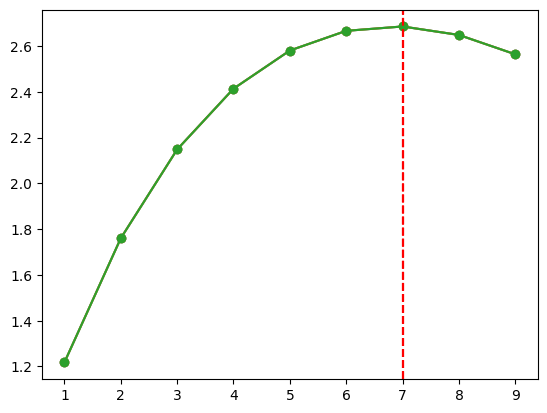

In [69]:
for data_dict_l in data_dict_l_l:
    data_ratio = []
    for data_dict in data_dict_l:
        X = data_dict['X'].cpu().numpy()
        y = data_dict['y'].cpu().numpy()
        # data_ratio.append((X.shape[0]*(y.shape[1]-1))/(X.shape[1]+y.shape[1]))
        data_ratio.append(X.shape[0]/(X.shape[1]+y.shape[1]))
    plt.plot(var_values, data_ratio, marker='o')
    plt.axvline(var_values[np.argmax(data_ratio)], c='red', linestyle='--')

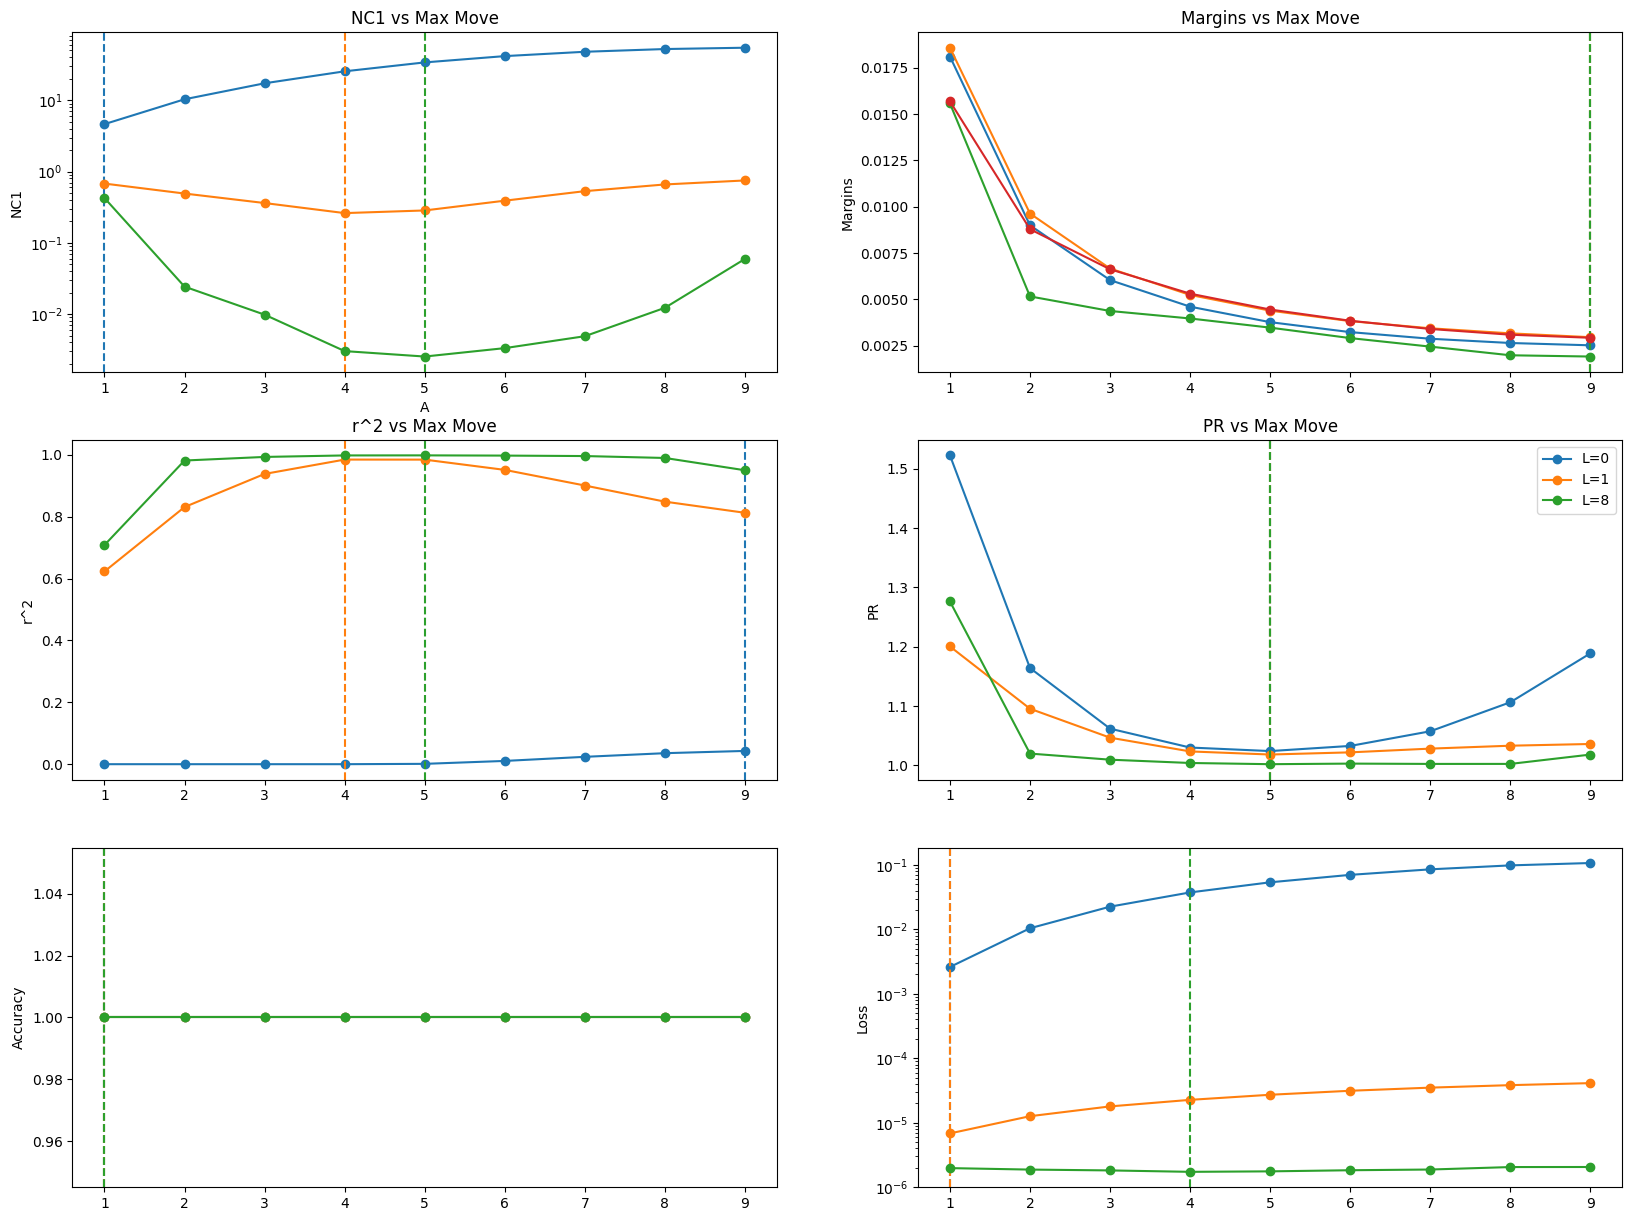

In [70]:
from matplotlib.colors import TABLEAU_COLORS

colors = list(TABLEAU_COLORS.values())
fig, axs = plt.subplots(3, 2, figsize=(20, 15))
axs = axs.flatten()
axs[0].set_title('NC1 vs Max Move')
axs[1].set_title('Margins vs Max Move')
axs[2].set_title('r^2 vs Max Move')
axs[3].set_title('PR vs Max Move')
for i, data_dict_l in enumerate(data_dict_l_l):
    NC1_l = []
    margins_l = []
    r_2_l = []
    PR_l = []
    accuracy_l = []
    loss_l = []
    for data_dict in data_dict_l:
        NC1_l.append(calc_NC1_from_data_dict(data_dict))
    
        X = data_dict['X'].cpu().numpy()
        y = data_dict['y'].cpu().numpy()
        state_dict = data_dict['final_weights']
        W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
        margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y, reducer=np.min)
        margins_l.append(margins)
        hidden = data_dict['hidden_states'][-1]
        loc_y = data_dict['loc_y']
        r_2_l.append(get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y))
        PR_l.append(calc_PR(W))
        accuracy_l.append(data_dict['accuracy_l'][-1])
        loss_l.append(data_dict['loss_l'][-1])
    axs[0].plot(var_values, NC1_l, marker='o')
    axs[0].axvline(var_values[np.argmin(NC1_l)], c=colors[i], linestyle='--')
    axs[0].set_xticks(var_values)
    axs[0].set_yscale('log')
    axs[0].set_xlabel('A')
    axs[0].set_ylabel('NC1')
    axs[1].plot(var_values, margins_l, marker='o')
    axs[1].axvline(var_values[np.argmin(margins_l)], c=colors[i], linestyle='--')
    axs[1].set_ylabel('Margins')
    axs[2].plot(var_values, r_2_l, marker='o')
    axs[2].axvline(var_values[np.argmax(r_2_l)], c=colors[i], linestyle='--')
    axs[2].set_ylabel('r^2')
    axs[3].plot(var_values, PR_l, marker='o', label=f'{var_name2}={var_values2[i]}')
    axs[3].axvline(var_values[np.argmin(PR_l)], c=colors[i], linestyle='--')
    axs[3].set_ylabel('PR')
    axs[4].plot(var_values, accuracy_l, marker='o', label=f'{var_name2}={var_values2[i]}')
    axs[4].axvline(var_values[np.argmax(accuracy_l)], c=colors[i], linestyle='--')
    axs[4].set_ylabel('Accuracy')
    axs[5].plot(var_values, loss_l, marker='o', label=f'{var_name2}={var_values2[i]}')
    axs[5].axvline(var_values[np.argmin(loss_l)], c=colors[i], linestyle='--')
    axs[5].set_ylabel('Loss')
    axs[5].set_yscale('log')
axs[3].legend()

margins_l = []
for i, data_dict in enumerate(data_dict_l_l[0]):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    W_LP = W_LP_l[i]
    margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W_LP, X, y, reducer=np.min)
    margins_l.append(margins)
axs[1].plot(var_values, margins_l, marker='o')

In [71]:
TABLEAU_COLORS.values()

dict_values(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

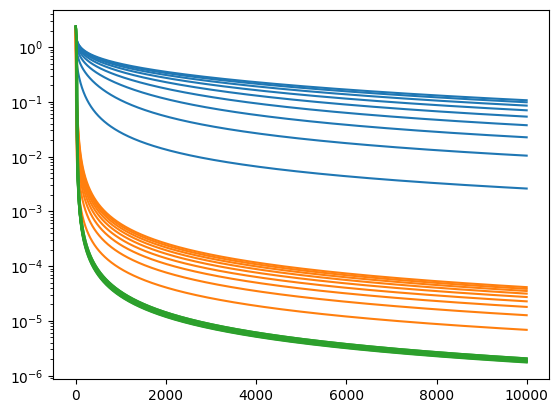

In [80]:
for i, data_dict_l in enumerate(data_dict_l_l):
    for data_dict in data_dict_l:
        plt.plot(data_dict['loss_l'], c=colors[i])
plt.yscale('log')


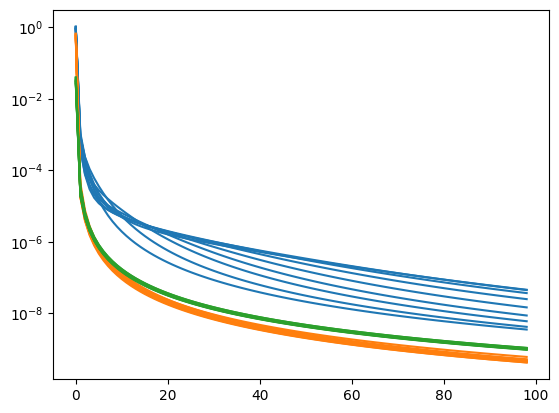

In [78]:
for i, data_dict_l in enumerate(data_dict_l_l):
    for data_dict in data_dict_l:
        theta_l = [state_dict_to_theta(d)[0] for d in data_dict['state_dict_l']]
        sim_l = [cosine_similarity(t1, t2) for t1, t2 in zip(theta_l[:-1], theta_l[1:])]
        plt.plot(1-np.array(sim_l), c=colors[i])
plt.yscale('log')


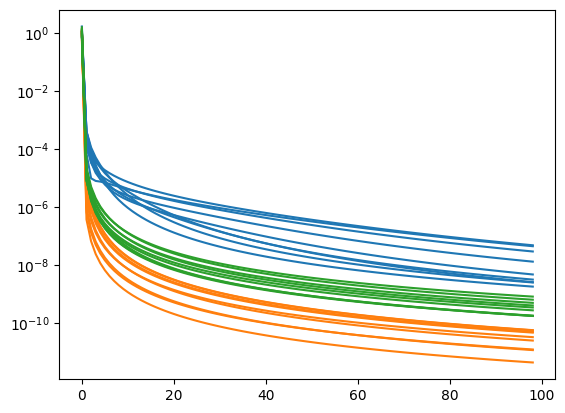

In [79]:
for i, data_dict_l in enumerate(data_dict_l_l):
    for data_dict in data_dict_l:
        W_l = [get_effective_W_from_model_dict(d)[0] for d in data_dict['state_dict_l']]
        sim_l = [cosine_similarity(W1.flatten(), W2.flatten()) for W1, W2 in zip(W_l[:-1], W_l[1:])]
        plt.plot(1-np.array(sim_l), c=colors[i])
plt.yscale('log')
plt.show()


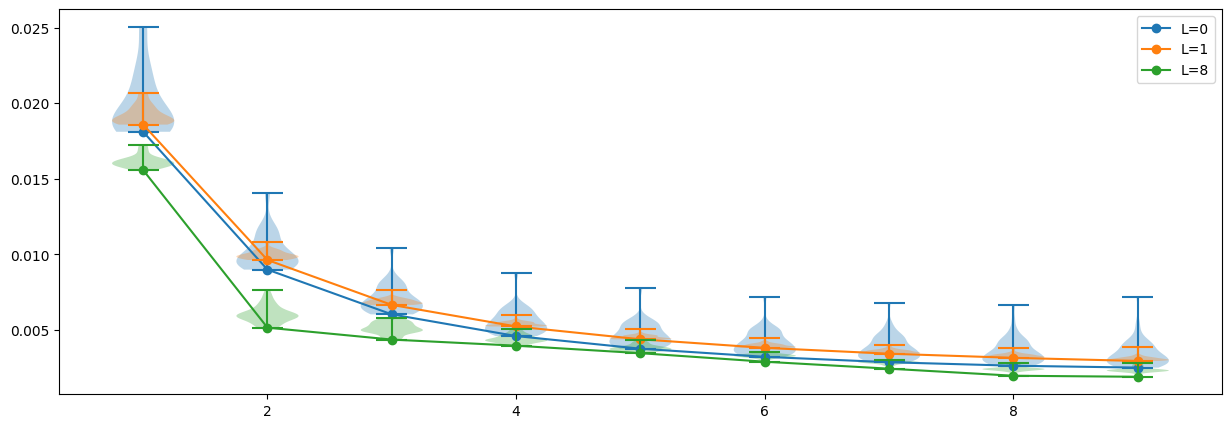

In [81]:

plt.figure(figsize=(15, 5))
# plt.yscale('log')
for i, data_dict_l in enumerate(data_dict_l_l):
    margins_l = []
    min_margins_l = []
    for data_dict in data_dict_l:
        X = data_dict['X'].cpu().numpy()
        y = data_dict['y'].cpu().numpy()
        state_dict = data_dict['final_weights']
        W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
        margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y, reducer=np.array, )
        margins_l.append(margins)
        min_margins_l.append(np.min(margins))

    b = plt.violinplot(margins_l, positions=var_values)
    plt.plot(var_values, min_margins_l, '-o', c=colors[i], label=f'{var_name2}={var_values2[i]}')
plt.legend()
plt.show()

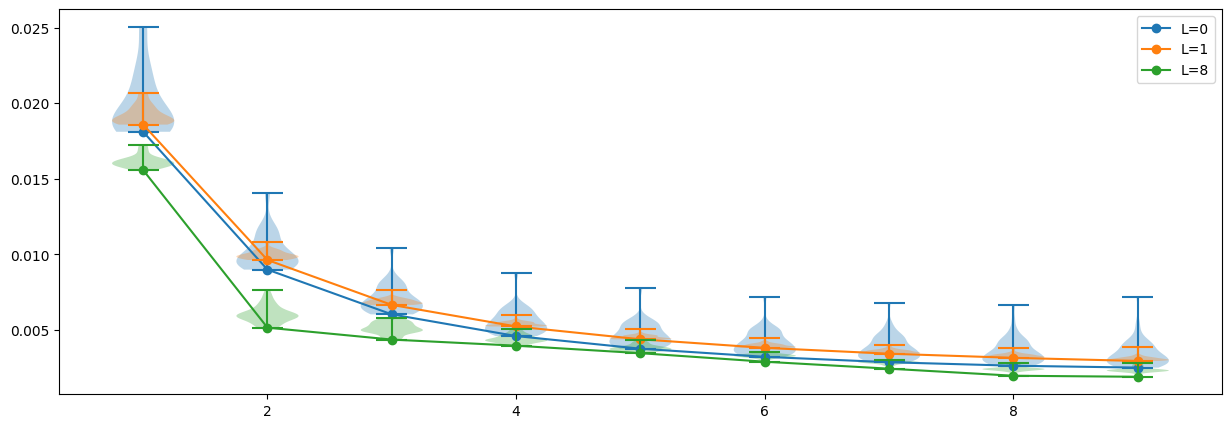

In [75]:

plt.figure(figsize=(15, 5))
# plt.yscale('log')
for i, data_dict_l in enumerate(data_dict_l_l):
    margins_l = []
    min_margins_l = []
    for data_dict in data_dict_l:
        X = data_dict['X'].cpu().numpy()
        y = data_dict['y'].cpu().numpy()
        state_dict = data_dict['final_weights']
        W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
        margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y, reducer=np.array, )
        margins_l.append(margins)
        min_margins_l.append(np.min(margins))

    b = plt.violinplot(margins_l, positions=var_values)
    plt.plot(var_values, min_margins_l, '-o', c=colors[i], label=f'{var_name2}={var_values2[i]}')
plt.legend()
plt.show()

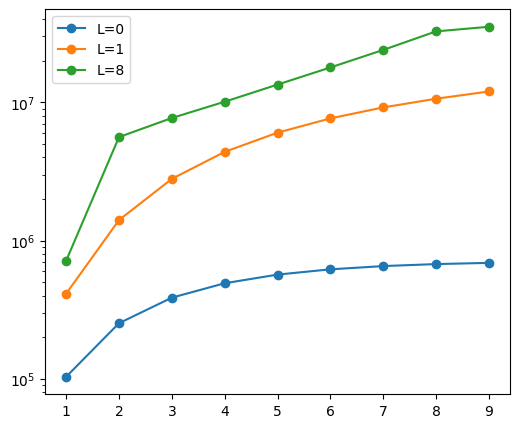

In [84]:
plt.figure(figsize=(6, 5))
# plt.yscale('log')
for i, data_dict_l in enumerate(data_dict_l_l):
    norm_l = []
    for data_dict in data_dict_l:
        X = data_dict['X'].cpu().numpy()
        y = data_dict['y'].cpu().numpy()
        state_dict = data_dict['final_weights']
        W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
        norm_l.append(np.linalg.norm(W)**2)
    plt.plot(var_values, norm_l, '-o', c=colors[i], label=f'{var_name2}={var_values2[i]}')
plt.legend()
plt.yscale('log')
plt.show()

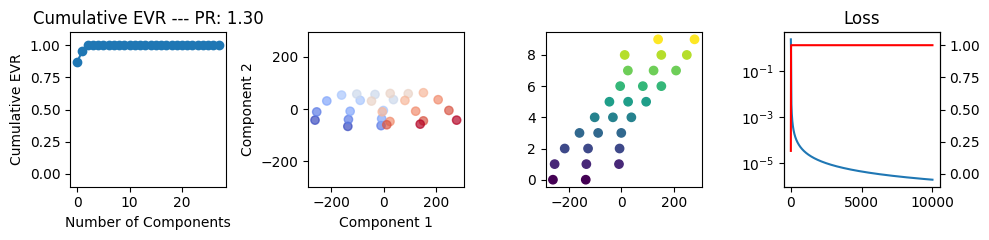

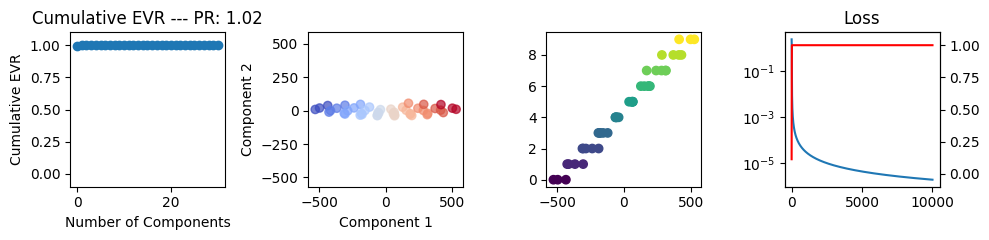

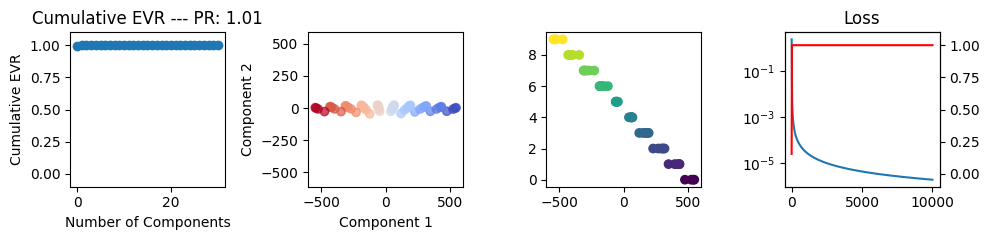

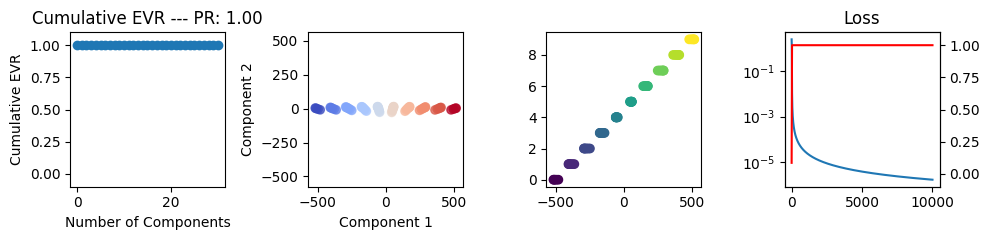

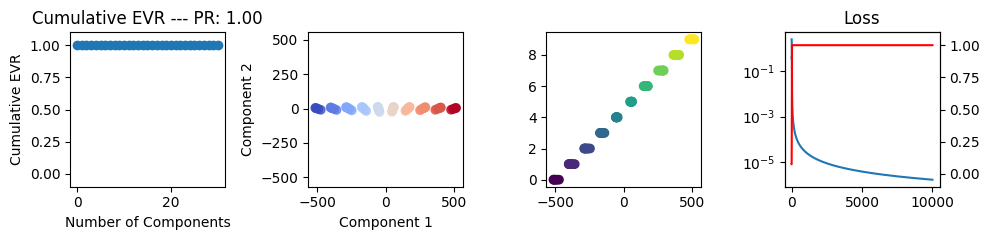

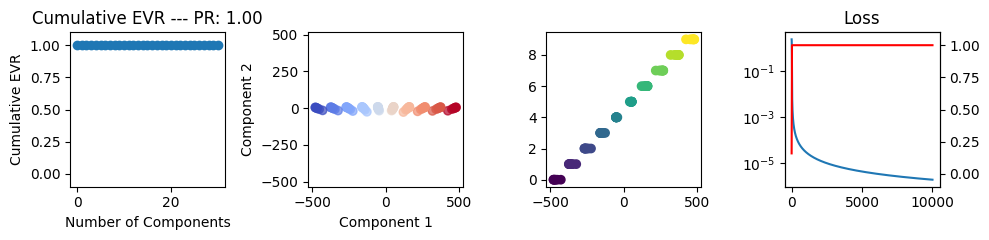

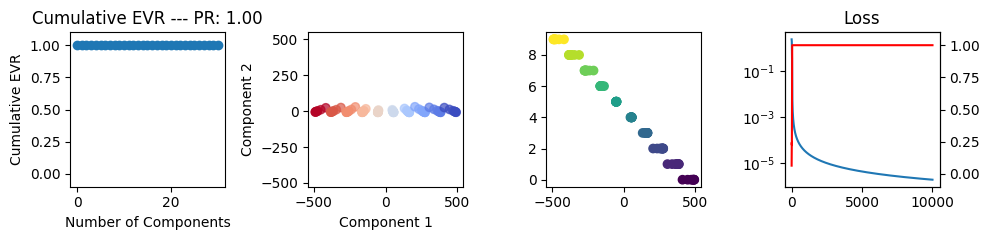

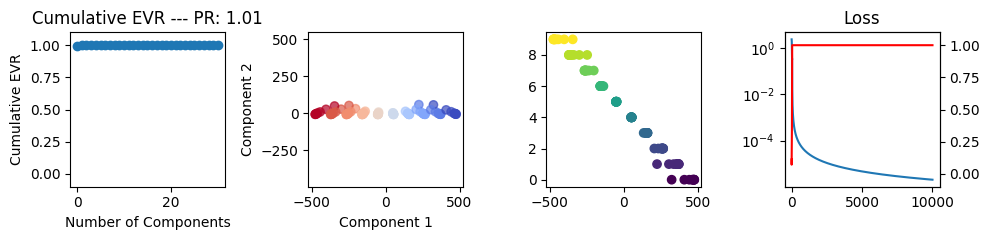

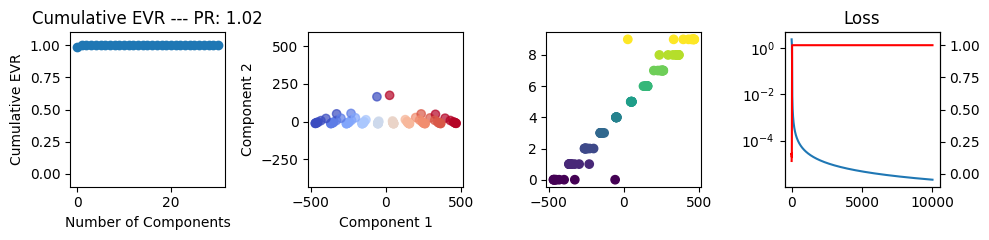

In [76]:
for data_dict in data_dict_l_l[-1]:
    # plot_loss_and_dist(data_dict)
    plot_pca(data_dict)

In [77]:
stop

NameError: name 'stop' is not defined

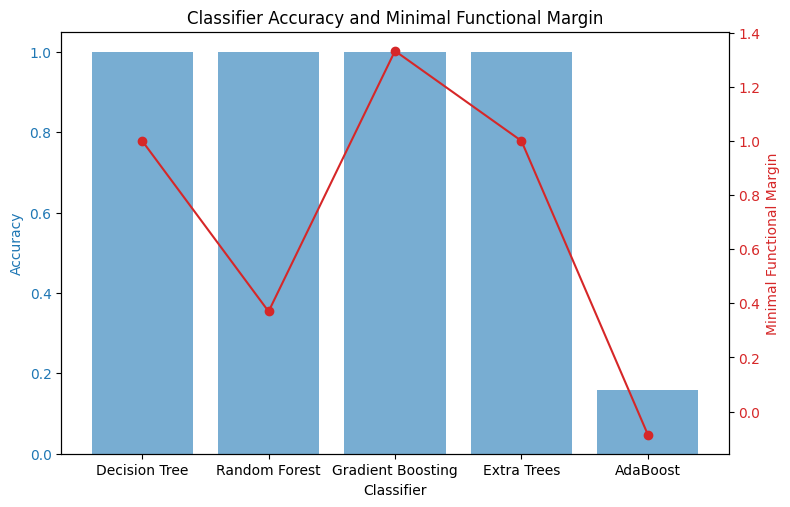

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Prepare data
X = data_dict_l_l[0][5]['X'].cpu().numpy()
y = data_dict_l_l[0][5]['y'].cpu().numpy().argmax(1)

# Define classifiers (no SVM, no neural net)
classifiers = {
    "Decision Tree": DecisionTreeClassifier(max_depth=100),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Train, predict, and compute accuracy and minimal functional margins, then plot
import matplotlib.pyplot as plt

acc_list = []
min_margin_list = []
clf_names = []

for name, clf in classifiers.items():
    clf.fit(X, y)
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    # Functional margin: difference between the score for the true class and the max score for other classes
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X)
    elif hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X)
    else:
        print(f"{name}: Cannot compute functional margin (no scores available)")
        continue

    if scores.ndim == 1:  # Binary case
        scores = np.stack([-scores, scores], axis=1)
    true_scores = scores[np.arange(len(y)), y]
    scores[np.arange(len(y)), y] = -np.inf
    max_other_scores = np.max(scores, axis=1)
    functional_margins = true_scores - max_other_scores

    acc_list.append(acc)
    min_margin_list.append(np.min(functional_margins))
    clf_names.append(name)

# Plotting
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Classifier')
ax1.set_ylabel('Accuracy', color=color)
ax1.bar(clf_names, acc_list, color=color, alpha=0.6, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Minimal Functional Margin', color=color)
ax2.plot(clf_names, min_margin_list, color=color, marker='o', label='Min Functional Margin')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title("Classifier Accuracy and Minimal Functional Margin")
plt.show()

In [ ]:
clf.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

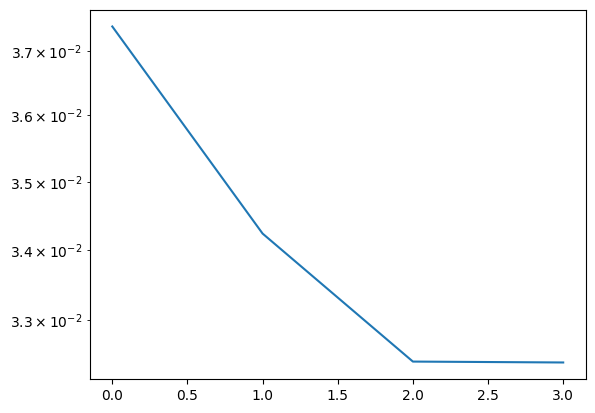

In [ ]:
margins_l = []
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    state_dict = data_dict['final_weights']
    W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
    margins, min_margin_idx, i_max_other_score = multiclass_functional_margin(W, X, y, reducer=np.min)
    margins_l.append(margins)

plt.plot(margins_l)
plt.yscale('log')
plt.show()

In [ ]:
state_dict_l = data_dict['state_dict_l']
theta_l = [state_dict_to_theta(state_dict)[0].cpu().numpy() for state_dict in state_dict_l]

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Stack all theta vectors into a 2D array
theta_mat = np.stack(theta_l)
# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(theta_mat)
print("Cosine similarity matrix between all theta in theta_l:")
plt.plot(np.diag(similarity_matrix, 1))


KeyError: 'state_dict_l'

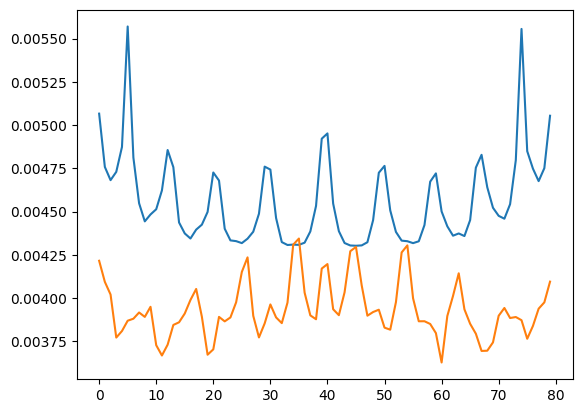

100%|██████████| 100000/100000 [00:50<00:00, 1960.89it/s]


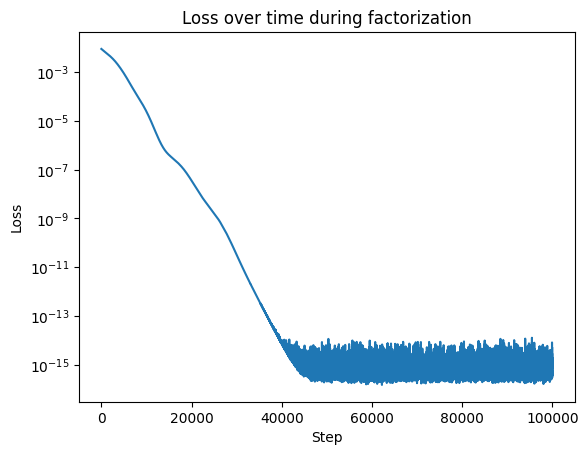

In [ ]:
W_target = get_effective_W_from_model_dict(data_dict_l[0]['final_weights']).cpu().numpy()
W_curr = get_effective_W_from_model_dict(data_dict_l[1]['final_weights']).cpu().numpy()
W_target = W_target / np.linalg.norm(W_target)
W_curr = W_curr / np.linalg.norm(W_curr)

scores = X@W_target
true_scores = scores[np.arange(len(y)), y.argmax(axis=1)]
scores[np.arange(len(y)), y.argmax(axis=1)] = 0
max_other_scores = np.max(scores, axis=1)
plt.plot(true_scores - max_other_scores)
scores = X@W_curr
true_scores = scores[np.arange(len(y)), y.argmax(axis=1)]
scores[np.arange(len(y)), y.argmax(axis=1)] = 0
max_other_scores = np.max(scores, axis=1)
plt.plot(true_scores - max_other_scores)
plt.show()

W_l_target = factorize_matrix_to_L_matrices(torch.tensor(W_target), 3, N=C.hidden_size, n_steps=100000, lr=0.00001, verbose=True)

In [ ]:
state_dict_new = {k: v for k, v in zip(data_dict_l[1]['final_weights'].keys(), W_l_target) if 'weight' in k}
print([w.shape for w in W_l_target])
print([w.shape for w in data_dict_l[1]['final_weights'].values()])
print([w.shape for w in state_dict_new.values()])
W_effective_target = get_effective_W_from_model_dict(state_dict_new)

print(multiclass_functional_margin(W_effective_target.cpu().numpy(), X, y, reducer=np.min))
print(multiclass_functional_margin(W_target, X, y, reducer=np.min))
print(multiclass_functional_margin(W_curr, X, y, reducer=np.min))

[torch.Size([21, 21]), torch.Size([21, 21]), torch.Size([10, 21])]
[torch.Size([21, 21]), torch.Size([21, 21]), torch.Size([10, 21])]
[torch.Size([21, 21]), torch.Size([21, 21]), torch.Size([10, 21])]
(0.004302319, 45, 5)
(0.004302345, 45, 5)
(0.003627427, 60, 3)


In [ ]:
C.L = 2
C.num_epochs = 1
C.learning_rate = 0.001
torch.save(state_dict_new, 'model_state_dict.pth')
C.state_dict_path = 'model_state_dict.pth'
data_dict_new = run_sim_wrapper(C)


Number of samples: 80
Input dimension: 21
Output dimension: 10
Number of actions: 11

Changed G to 0.5835782289505005 to get sig_h_2 = 0.01
Sig_2 of last hidden: 0.018091408535838127


100%|██████████| 1/1 [00:00<00:00, 375.33it/s]


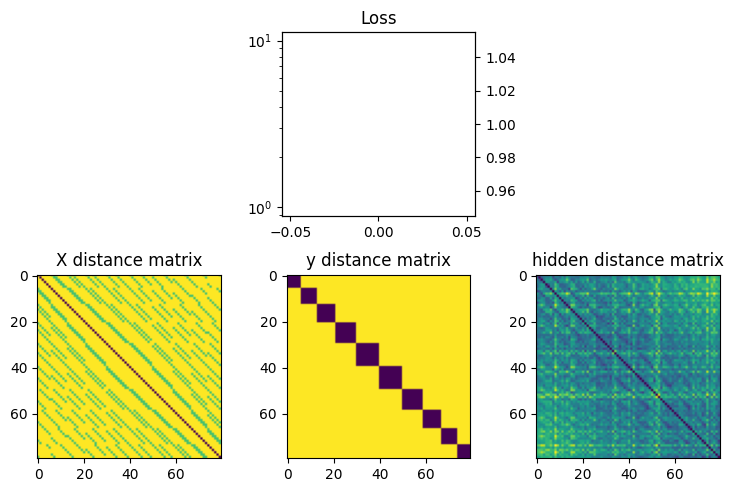

In [ ]:
plot_loss_and_dist(data_dict_new)

In [ ]:

W_effective_converged = get_effective_W_from_model_dict(data_dict_new['final_weights'])
print(multiclass_functional_margin(W_effective_converged.cpu().numpy(), X, y, reducer=np.min))

(0.0042978674, 33, 2)


In [ ]:
data_dict_new['initial_weights'] = data_dict_new['final_weights']

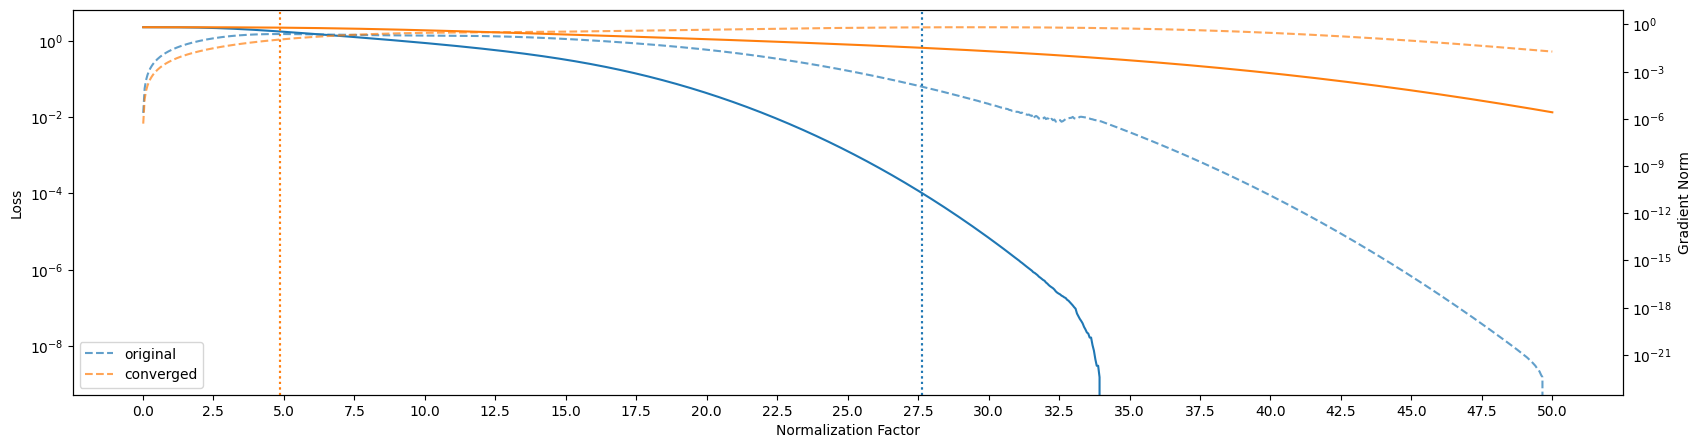

In [ ]:
plot_solution_direction_loss_space([data_dict_l[1], data_dict_new], ['original', 'converged'])

100%|██████████| 100000/100000 [00:39<00:00, 2530.28it/s]


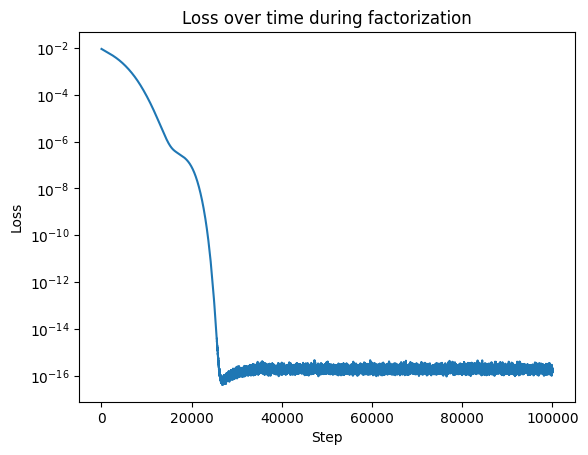

[torch.Size([21, 21]), torch.Size([10, 21])]
[torch.Size([21, 21]), torch.Size([10, 21])]
[torch.Size([21, 21]), torch.Size([10, 21])]
(0.0043023825, 45, 5)
(0.004302345, 45, 5)
Number of samples: 80
Input dimension: 21
Output dimension: 10
Number of actions: 11

Changed G to 0.34056356549263 to get sig_h_2 = 0.01
Sig_2 of last hidden: 0.028828220441937447


100%|██████████| 1/1 [00:00<00:00, 501.53it/s]

(0.004300803, 44, 3)


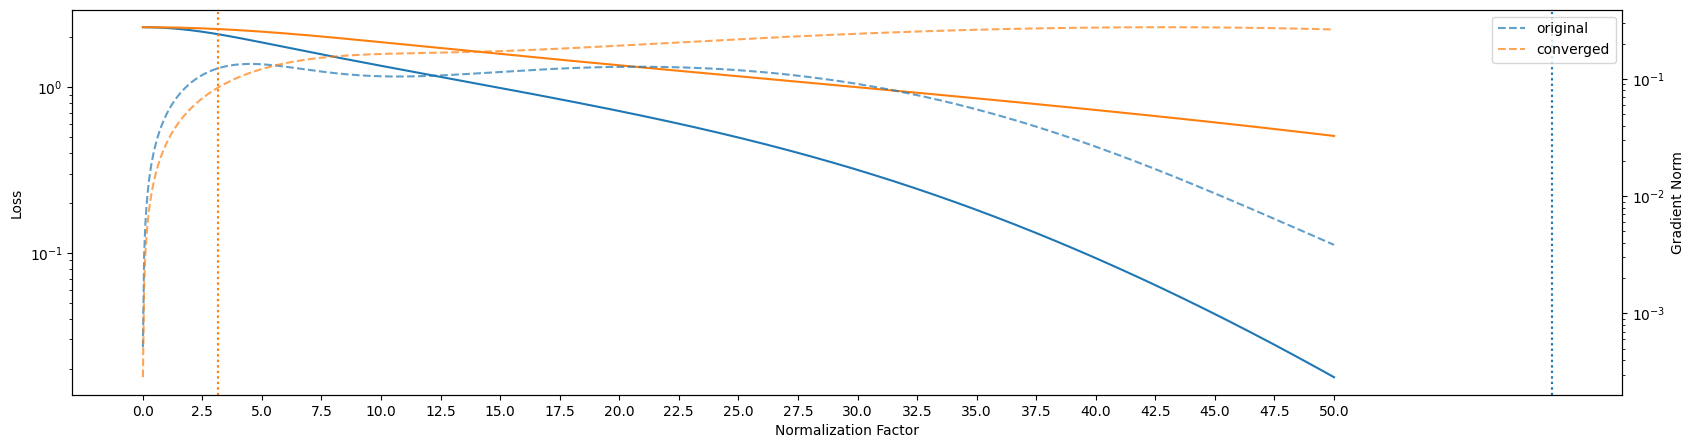

In [ ]:

W_l_target = factorize_matrix_to_L_matrices(torch.tensor(W_target), 2, N=C.hidden_size, n_steps=100000, lr=0.00001, verbose=True)
state_dict_new = {k: v for k, v in zip(data_dict_l[0]['final_weights'].keys(), W_l_target) if 'weight' in k}
print([w.shape for w in W_l_target])
print([w.shape for w in data_dict_l[0]['final_weights'].values()])
print([w.shape for w in state_dict_new.values()])
W_effective_target = get_effective_W_from_model_dict(state_dict_new)

print(multiclass_functional_margin(W_effective_target.cpu().numpy(), X, y, reducer=np.min))
print(multiclass_functional_margin(W_target, X, y, reducer=np.min))


Number of samples: 80
Input dimension: 21
Output dimension: 10
Number of actions: 11

Changed G to 0.34056356549263 to get sig_h_2 = 0.01
Sig_2 of last hidden: 0.028828220441937447


100%|██████████| 10000/10000 [00:06<00:00, 1517.38it/s]


(0.003913697, 34, 3)


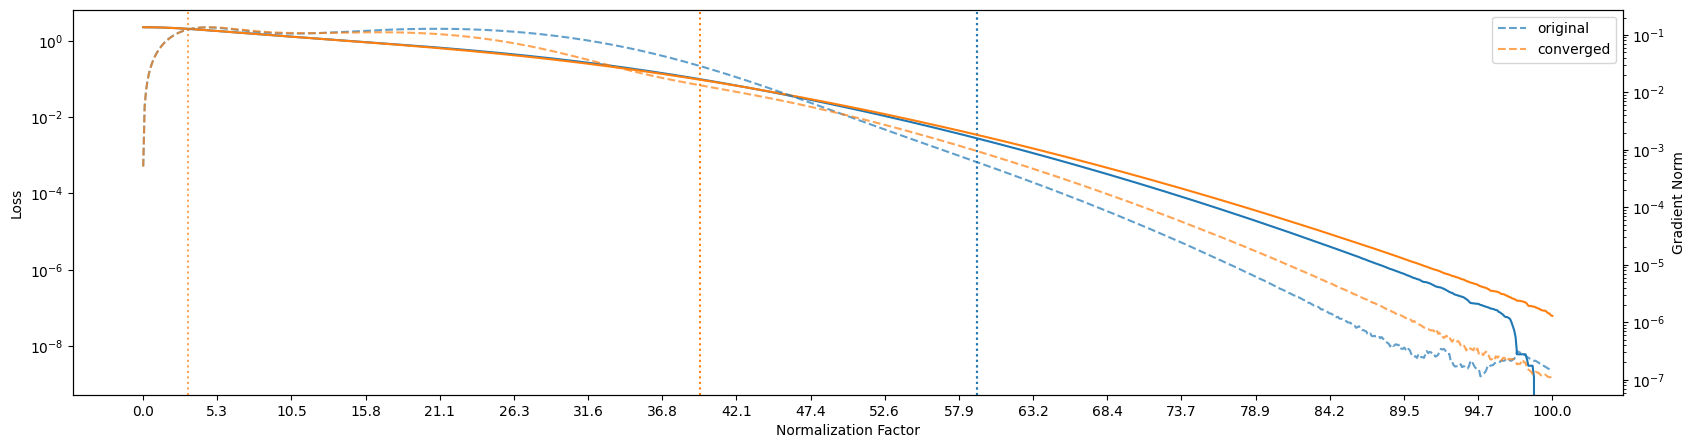

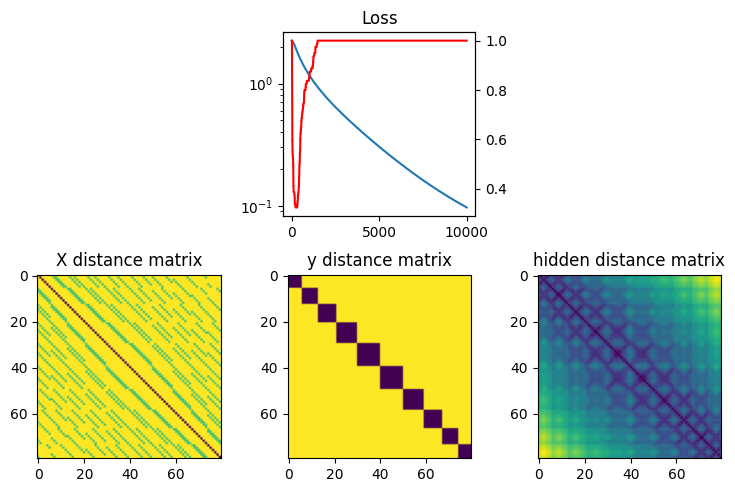

In [ ]:

C.L = 1
C.num_epochs = 10000
C.learning_rate = 0.1
torch.save(state_dict_new, 'model_state_dict.pth')
C.state_dict_path = 'model_state_dict.pth'
data_dict_new = run_sim_wrapper(C)

W_effective_converged = get_effective_W_from_model_dict(data_dict_new['final_weights'])
print(multiclass_functional_margin(W_effective_converged.cpu().numpy(), X, y, reducer=np.min))

plot_solution_direction_loss_space([data_dict_l[0], data_dict_new], ['original', 'converged'], max_norm=100)
plot_loss_and_dist(data_dict_new)

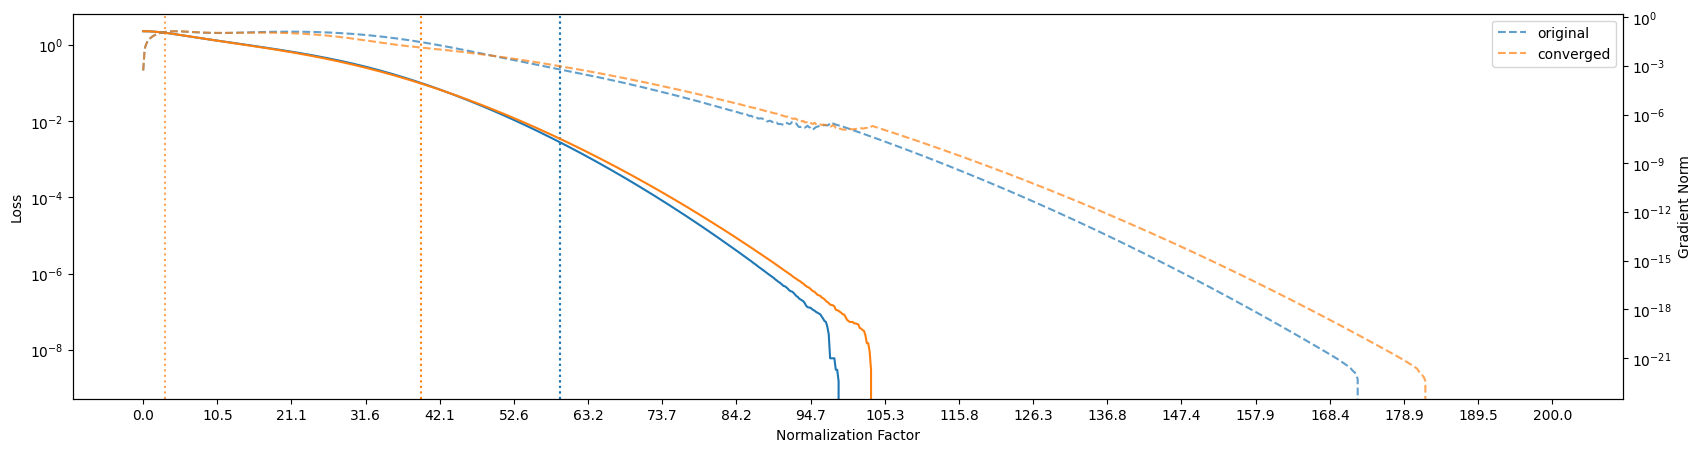

In [ ]:
plot_solution_direction_loss_space([data_dict_l[0], data_dict_new], ['original', 'converged'], max_norm=200)

In [ ]:
state_dict_new = {'output_layer.weight':torch.tensor(W_target).T}
print([w.shape for w in W_l_target])
print([w.shape for w in data_dict_l[0]['final_weights'].values()])
print([w.shape for w in state_dict_new.values()])

print(multiclass_functional_margin(W_effective_target.cpu().numpy(), X, y, reducer=np.min))
print(multiclass_functional_margin(W_target, X, y, reducer=np.min))

C.L = 0
C.sig_h_2 = None
C.G = 0.1
C.num_epochs = 1
C.learning_rate = 0.01
torch.save(state_dict_new, 'model_state_dict.pth')
C.state_dict_path = 'model_state_dict.pth'
data_dict_new = run_sim_wrapper(C)
C.num_epochs = 10000000
C.learning_rate = 0.1
C.state_dict_path = None
data_dict_converged = run_sim_wrapper(C)

[torch.Size([21, 21]), torch.Size([10, 21])]
[torch.Size([21, 21]), torch.Size([10, 21])]
[torch.Size([10, 21])]
(0.0043023825, 45, 5)
(0.004302345, 45, 5)
Number of samples: 80
Input dimension: 21
Output dimension: 10
Number of actions: 11

Sig_2 of last hidden: 0.08621912449598312


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 1003.90it/s]


Number of samples: 80
Input dimension: 21
Output dimension: 10
Number of actions: 11

Sig_2 of last hidden: 0.08621912449598312


100%|██████████| 10000000/10000000 [1:09:58<00:00, 2381.84it/s]


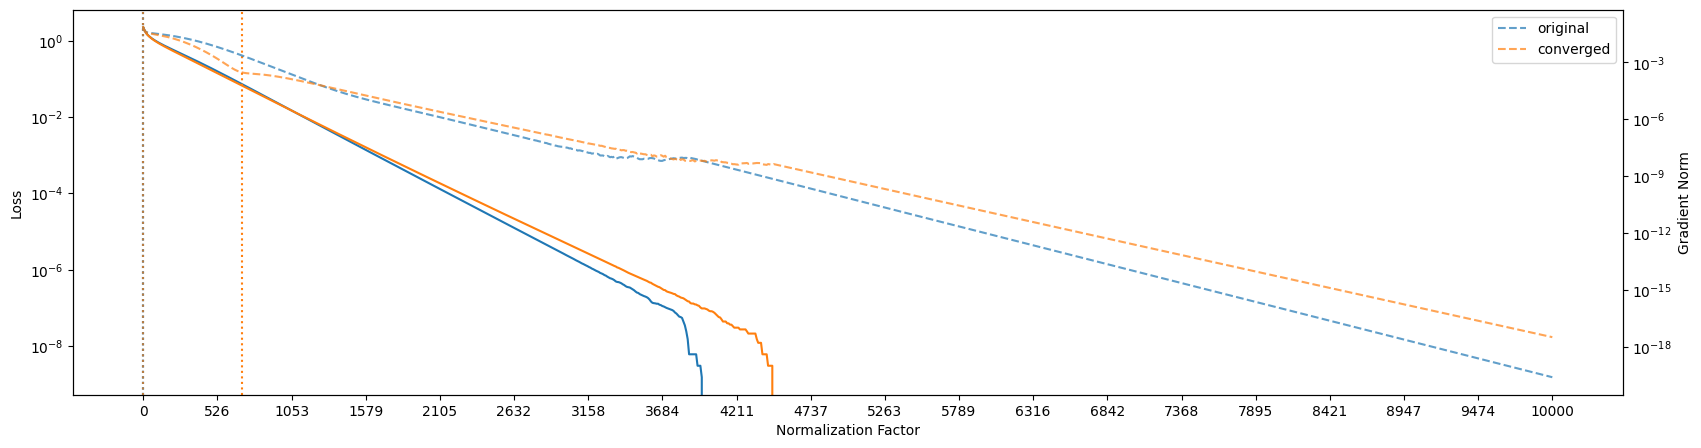

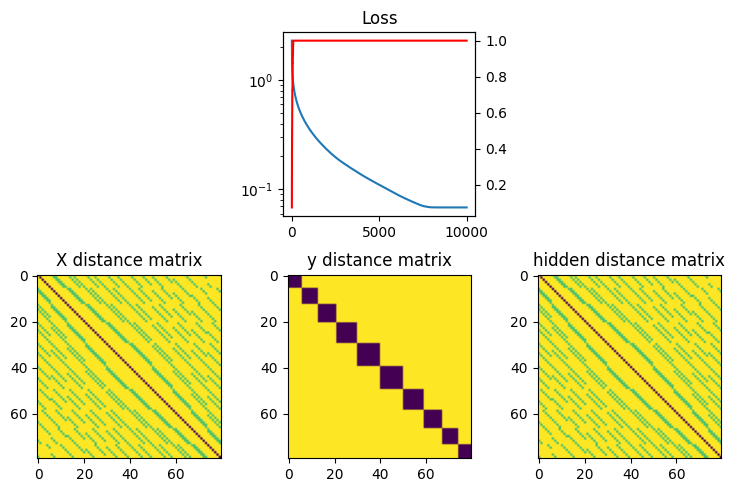

In [ ]:

plot_solution_direction_loss_space([data_dict_new, data_dict_converged], ['original', 'converged'], max_norm=10000)
plot_loss_and_dist(data_dict_converged)

In [ ]:
import run_sim
import model
import importlib
importlib.reload(model) 
importlib.reload(run_sim) 
from run_sim import *